In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import  BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold, LeavePOut
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import  SVR
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score

In [202]:
data=pd.read_csv('bitcoin_dataset.csv')
print(data)
data.describe()

           Date  btc_market_price  btc_total_bitcoins  btc_market_cap  \
0     2/17/2010           0.00000           2043200.0    0.000000e+00   
1     2/18/2010           0.00000           2054650.0    0.000000e+00   
2     2/19/2010           0.00000           2063600.0    0.000000e+00   
3     2/20/2010           0.00000           2074700.0    0.000000e+00   
4     2/21/2010           0.00000           2085400.0    0.000000e+00   
...         ...               ...                 ...             ...   
2901  1/27/2018       11524.77667          16830312.5    1.940000e+11   
2902  1/28/2018       11765.71000          16832287.5    1.980000e+11   
2903  1/29/2018       11212.65500          16834137.5    1.890000e+11   
2904  1/30/2018       10184.06167          16836225.0    1.710000e+11   
2905  1/31/2018       10125.01333          16837687.5    1.700000e+11   

      btc_trade_volume  btc_blocks_size  btc_avg_block_size  \
0         0.000000e+00           0.0000            0.000235 

,btc_market_price,btc_total_bitcoins,btc_market_cap,btc_trade_volume,btc_blocks_size,btc_avg_block_size,btc_n_orphaned_blocks,btc_n_transactions_per_block,btc_median_confirmation_time,btc_hash_rate,...,btc_cost_per_transaction_percent,btc_cost_per_transaction,btc_n_unique_addresses,btc_n_transactions,btc_n_transactions_total,btc_n_transactions_excluding_popular,btc_n_transactions_excluding_chains_longer_than_100,btc_output_volume,btc_estimated_transaction_volume,btc_estimated_transaction_volume_usd
count,2906.000000,2.879000e+03,2.906000e+03,2.885000e+03,2877.000000,2906.000000,2906.000000,2906.000000,2894.000000,2.906000e+03,...,2906.000000,2906.000000,2.906000e+03,2906.000000,2.906000e+03,2906.000000,2906.000000,2.906000e+03,2.906000e+03,2.906000e+03
mean,839.104218,1.151138e+07,1.344352e+10,7.398381e+07,35505.502848,0.350366,0.364074,671.673651,7.501113,1.244070e+06,...,66.747821,14.639125,1.937861e+05,102081.138334,6.844558e+07,94348.852374,63140.320028,1.566216e+06,2.036475e+05,2.024338e+08
std,2304.972497,4.200024e+06,3.866841e+10,2.924228e+08,43618.633821,0.353168,0.842259,689.561322,4.974549,2.924141e+06,...,1761.894646,20.536083,2.089146e+05,103896.929350,8.285341e+07,103966.111763,69687.052174,2.278910e+06,2.682781e+05,5.800513e+08
min,0.000000,2.043200e+06,0.000000e+00,0.000000e+00,0.000000,0.000216,0.000000,1.000000,0.000000,2.250000e-05,...,0.136531,0.000000,1.100000e+02,118.000000,4.124000e+04,118.000000,118.000000,6.150000e+03,7.000000e+00,0.000000e+00
25%,6.653465,8.485300e+06,5.363081e+07,2.916456e+05,781.000000,0.024177,0.000000,54.000000,6.066667,1.160880e+01,...,1.181945,4.156470,1.675475e+04,8025.250000,2.413376e+06,6813.500000,6765.500000,4.901712e+05,9.600325e+04,9.581680e+05
50%,235.130000,1.243115e+07,3.346869e+09,1.001414e+07,15183.000000,0.196022,0.000000,375.000000,7.916667,2.176189e+04,...,2.493564,7.822430,1.304450e+05,62337.000000,3.255271e+07,53483.000000,35283.500000,1.105205e+06,1.784685e+05,3.742576e+07
75%,594.191164,1.520051e+07,8.075525e+09,2.834038e+07,58293.000000,0.676065,0.000000,1232.995223,10.208333,1.035363e+06,...,5.915591,14.800589,3.603765e+05,190471.250000,1.080663e+08,185901.750000,113793.250000,2.031654e+06,2.588046e+05,1.312499e+08
max,19498.683330,1.683769e+07,3.270000e+11,5.352016e+09,154444.590300,1.110327,7.000000,2722.625000,47.733333,2.160975e+07,...,88571.428570,161.686071,1.072861e+06,490644.000000,2.966888e+08,470650.000000,318896.000000,4.599222e+07,5.825066e+06,5.760245e+09


In [203]:
data.head()

,Date,btc_market_price,btc_total_bitcoins,btc_market_cap,btc_trade_volume,btc_blocks_size,btc_avg_block_size,btc_n_orphaned_blocks,btc_n_transactions_per_block,btc_median_confirmation_time,...,btc_cost_per_transaction_percent,btc_cost_per_transaction,btc_n_unique_addresses,btc_n_transactions,btc_n_transactions_total,btc_n_transactions_excluding_popular,btc_n_transactions_excluding_chains_longer_than_100,btc_output_volume,btc_estimated_transaction_volume,btc_estimated_transaction_volume_usd
0,2/17/2010,0.0,2043200.0,0.0,0.0,0.0,0.000235,0,1.0,0.0,...,31.781022,0.0,241,244,41240,244,244,65173.13,36500.0,0.0
1,2/18/2010,0.0,2054650.0,0.0,0.0,0.0,0.000241,0,1.0,0.0,...,154.463801,0.0,234,235,41475,235,235,18911.74,7413.0,0.0
2,2/19/2010,0.0,2063600.0,0.0,0.0,0.0,0.000228,0,1.0,0.0,...,1278.516635,0.0,185,183,41658,183,183,9749.98,700.0,0.0
3,2/20/2010,0.0,2074700.0,0.0,0.0,0.0,0.000218,0,1.0,0.0,...,22186.687990,0.0,224,224,41882,224,224,11150.03,50.0,0.0
4,2/21/2010,0.0,2085400.0,0.0,0.0,0.0,0.000234,0,1.0,0.0,...,689.179876,0.0,218,218,42100,218,218,12266.83,1553.0,0.0


In [204]:
data.shape

(2906, 24)

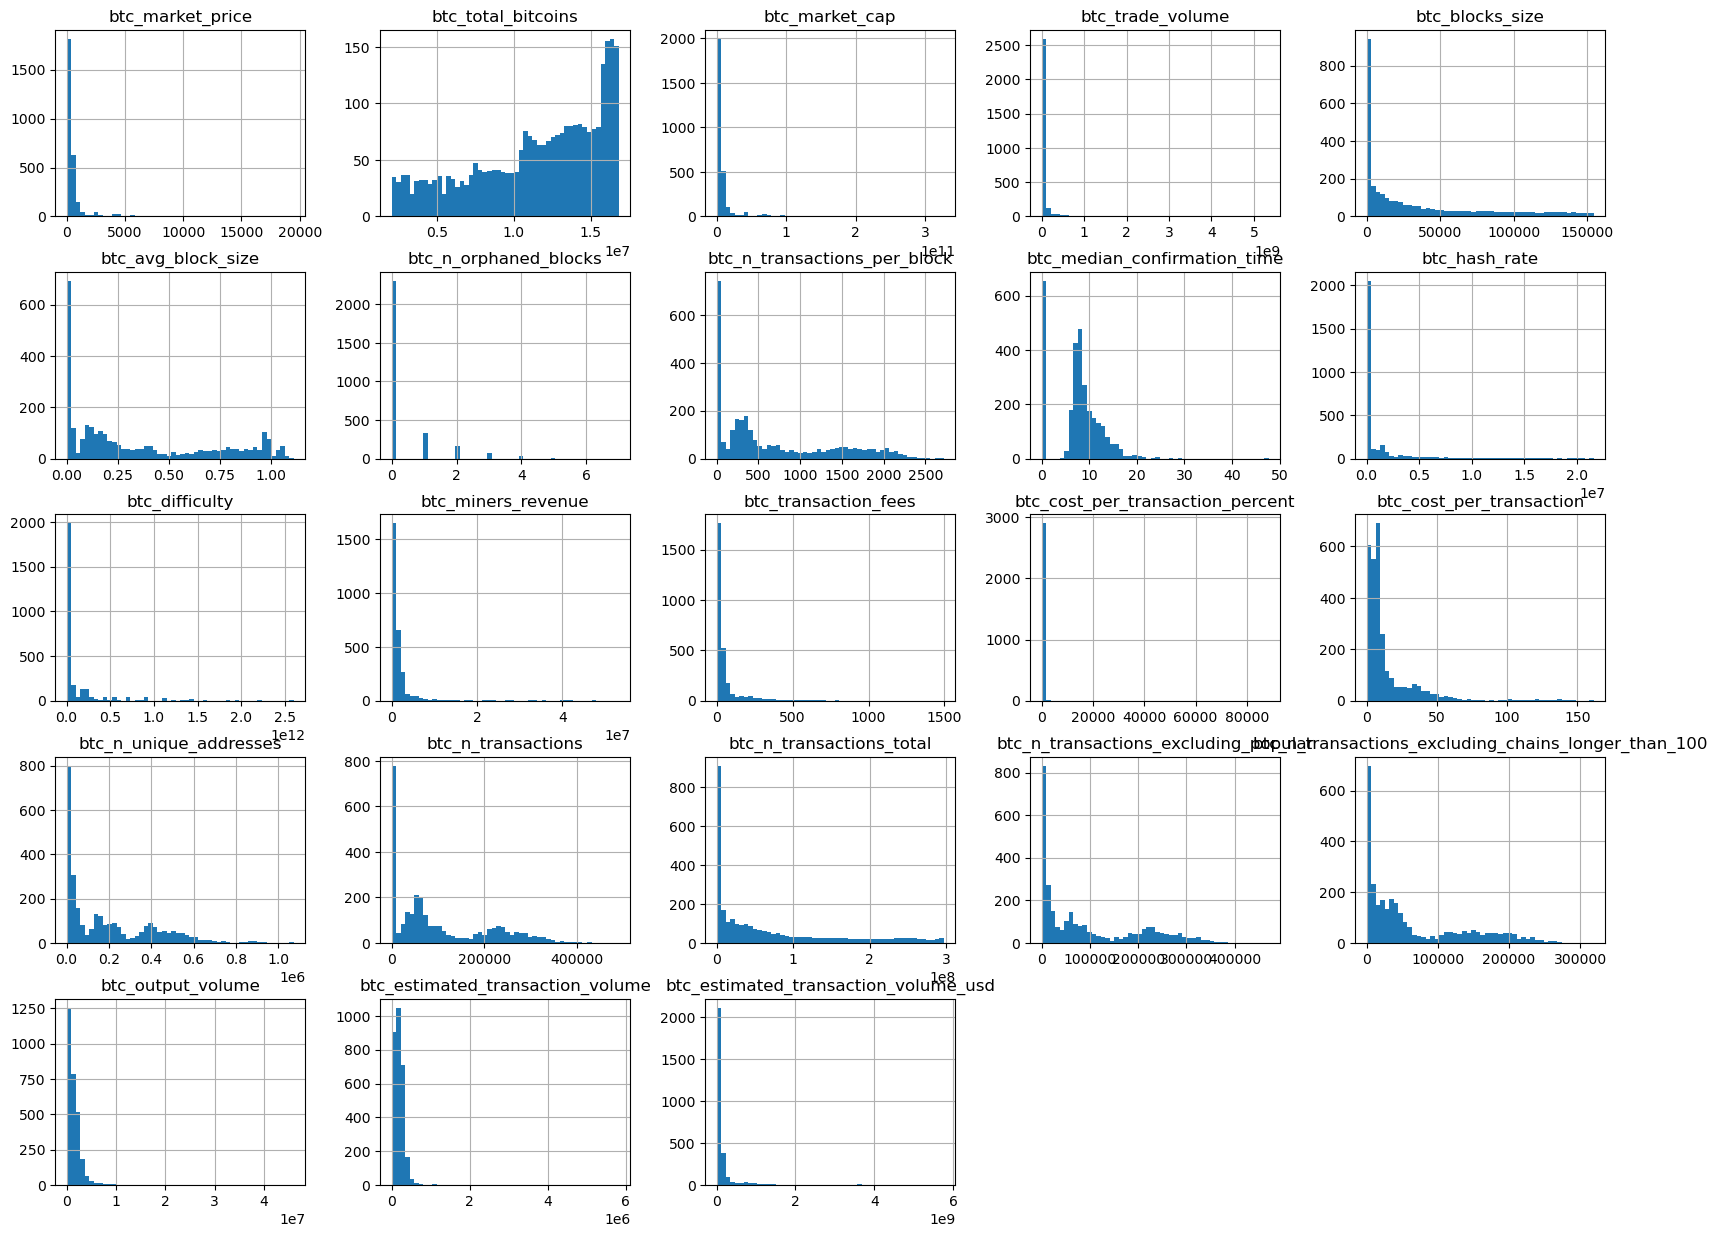

In [205]:
 #Visualiser les distributions des variables
import matplotlib.pyplot as plt
data.hist(bins=50, figsize=(20,15))
plt.show()

In [206]:
#data.btc_n_transactions_excluding_chains_longer_than_100.value_counts()

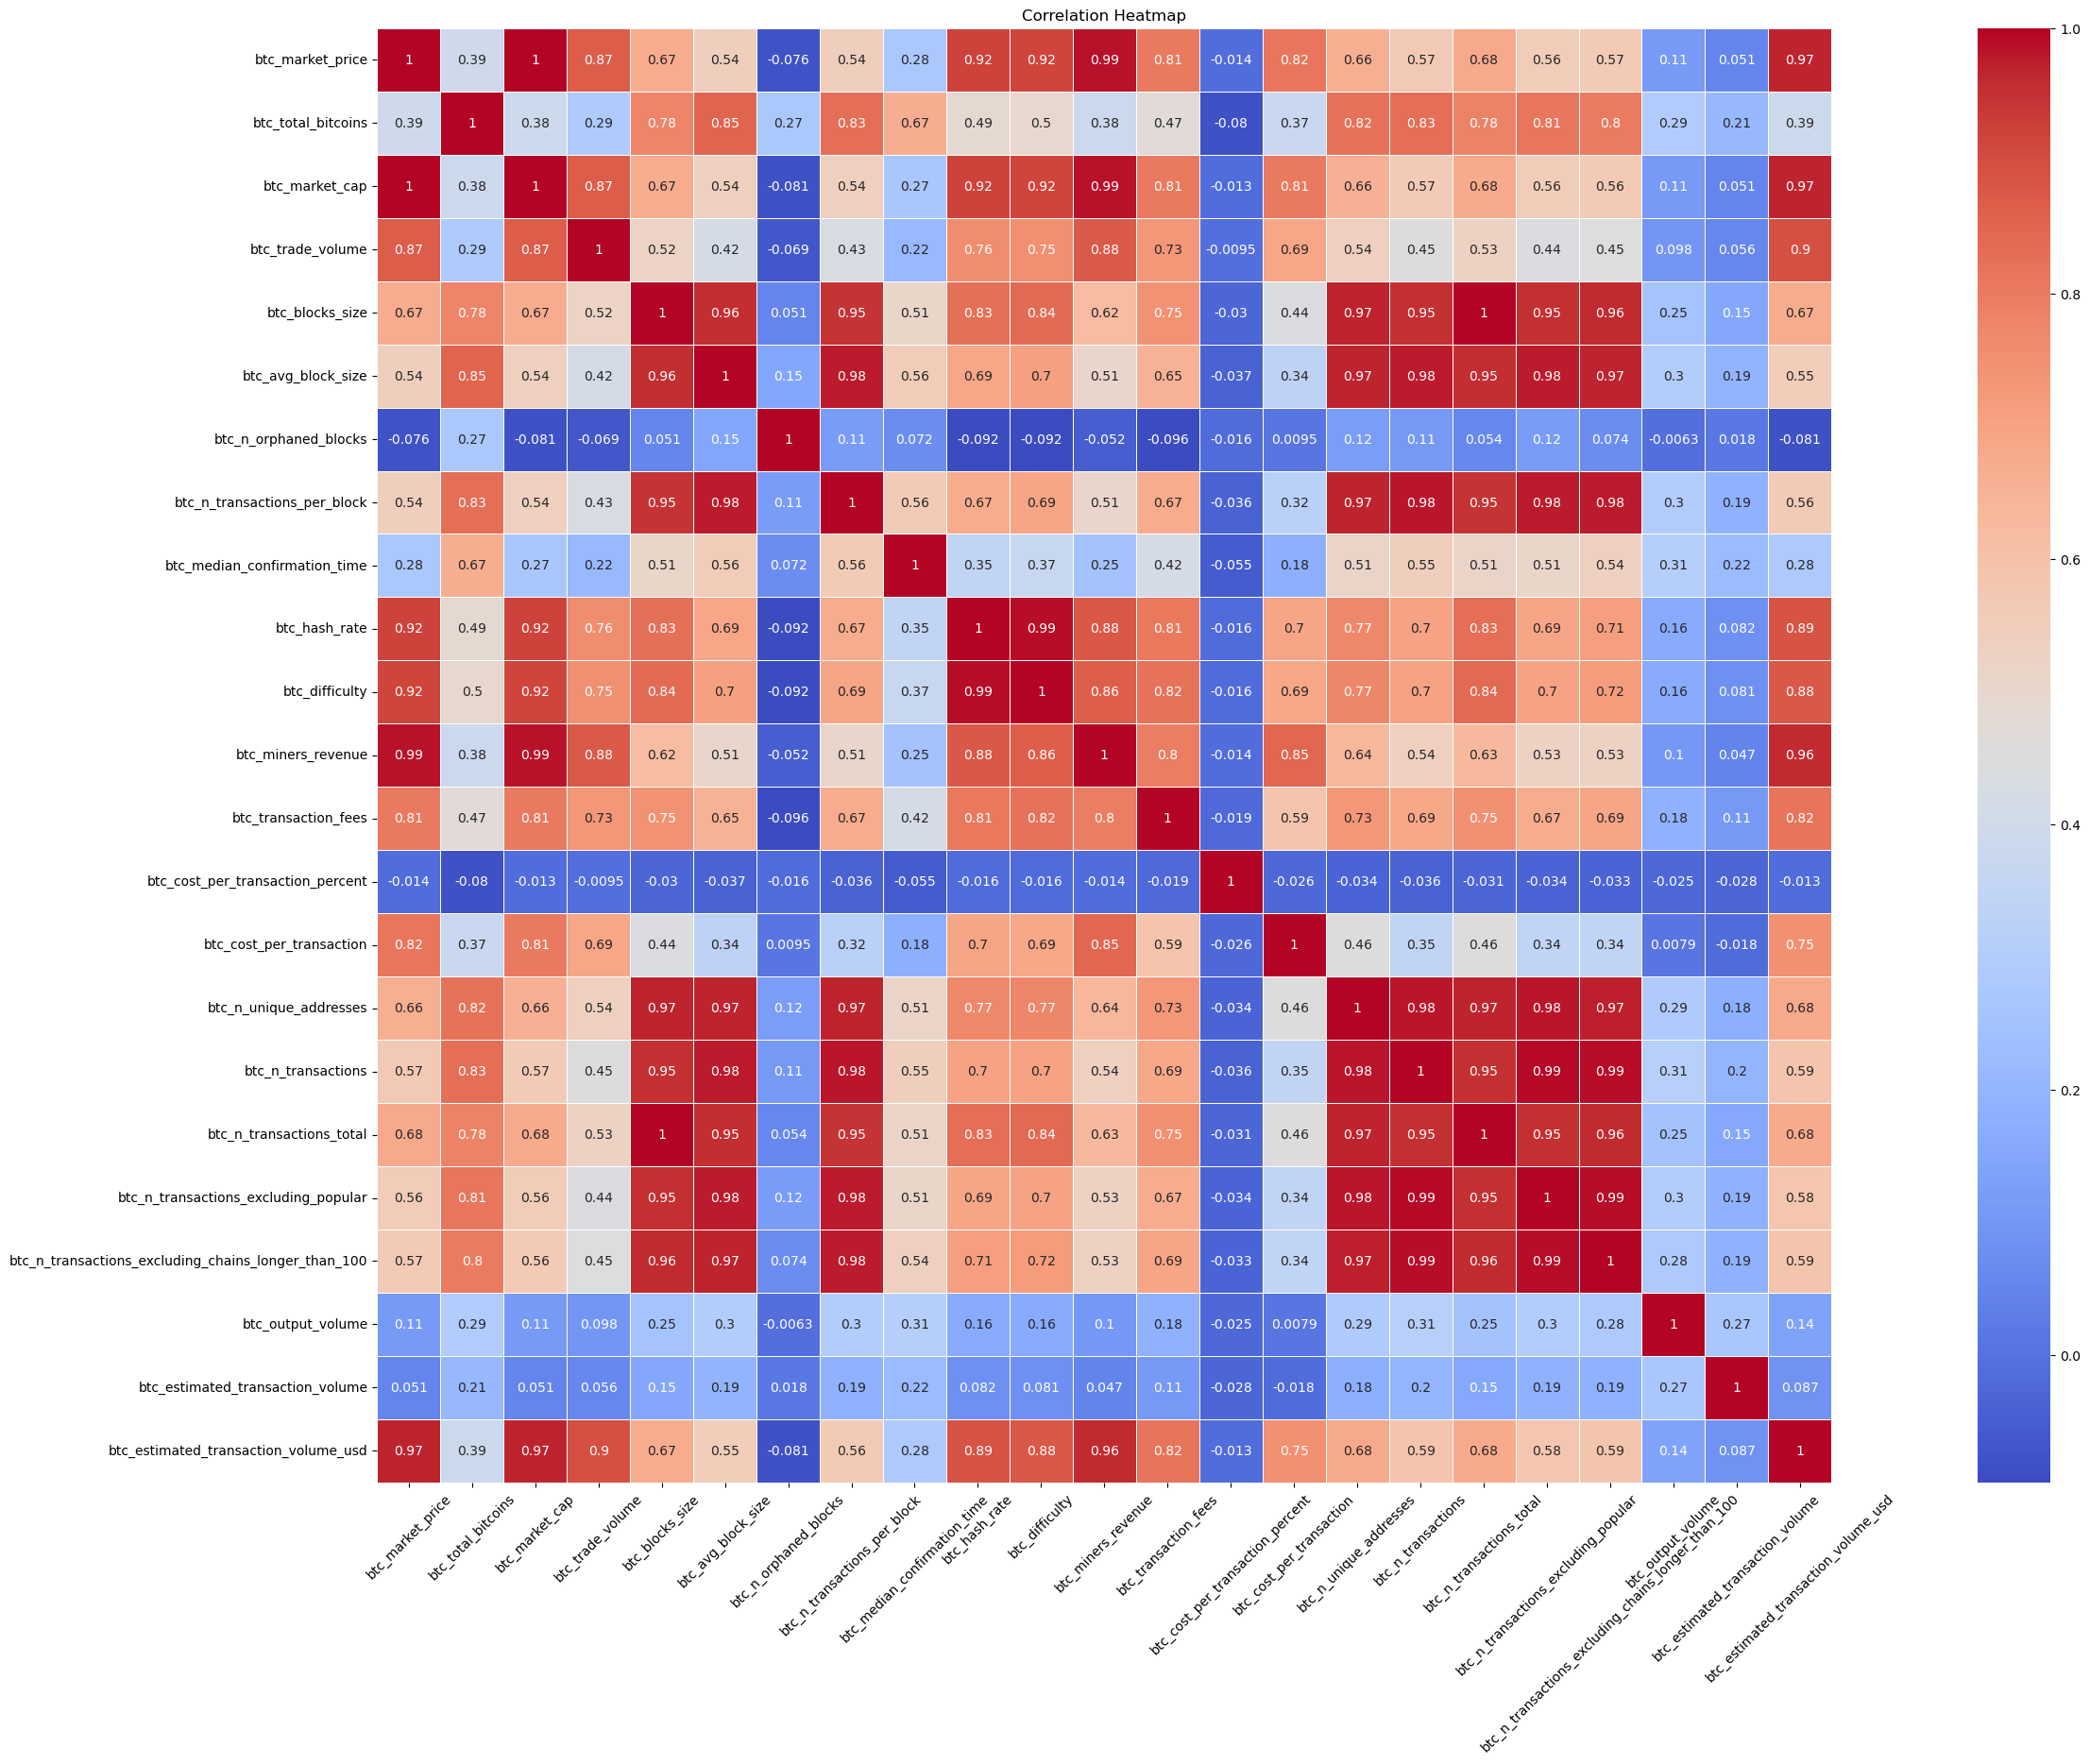

In [207]:
# Créer une figure de grande taille
plt.figure(figsize=(40, 20))

# Calculer la matrice de corrélation et générer le heatmap
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True, square=True, xticklabels=True, yticklabels=True)

# Ajuster les étiquettes des axes x et y pour une meilleure lisibilité
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)

# Ajouter un titre à la figure
plt.title('Correlation Heatmap', fontsize=12)

# Afficher la figure
plt.show()

In [208]:

data.isnull().sum()

Date                                                    0
btc_market_price                                        0
btc_total_bitcoins                                     27
btc_market_cap                                          0
btc_trade_volume                                       21
btc_blocks_size                                        29
btc_avg_block_size                                      0
btc_n_orphaned_blocks                                   0
btc_n_transactions_per_block                            0
btc_median_confirmation_time                           12
btc_hash_rate                                           0
btc_difficulty                                         16
btc_miners_revenue                                      0
btc_transaction_fees                                   10
btc_cost_per_transaction_percent                        0
btc_cost_per_transaction                                0
btc_n_unique_addresses                                  0
btc_n_transact

In [209]:
data=data.dropna()

In [210]:
data.isnull().sum()

Date                                                   0
btc_market_price                                       0
btc_total_bitcoins                                     0
btc_market_cap                                         0
btc_trade_volume                                       0
btc_blocks_size                                        0
btc_avg_block_size                                     0
btc_n_orphaned_blocks                                  0
btc_n_transactions_per_block                           0
btc_median_confirmation_time                           0
btc_hash_rate                                          0
btc_difficulty                                         0
btc_miners_revenue                                     0
btc_transaction_fees                                   0
btc_cost_per_transaction_percent                       0
btc_cost_per_transaction                               0
btc_n_unique_addresses                                 0
btc_n_transactions             

In [211]:
data.shape

(2791, 24)

In [212]:
# Trouver les lignes en double dans le Data :
duplicates = data.duplicated()
print(duplicates.sum())

0


In [213]:
#Détecter les valeurs aberrante :

# Calculer les statistiques descriptives (moyenne et écart-type)
mean = data.mean()
std = data.std()

# Définir les seuils supérieurs et inférieurs pour chaque attribut
threshold = 3  # Nombre d'écart-types pour définir les seuils
lower_threshold = mean - threshold * std
upper_threshold = mean + threshold * std

# Vérifier si chaque valeur est aberrante
outliers = (data < lower_threshold) | (data > upper_threshold)

# Afficher les valeurs aberrantes
aberrant_values = data[outliers]

# Afficher les lignes contenant des valeurs aberrantes
aberrant_rows = data[outliers.any(axis=1)]

# Supprimer les lignes contenant des valeurs aberrantes
cleaned_data1 = data[~outliers.any(axis=1)]

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8840\3366025717.py:4: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  mean = data.mean()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8840\3366025717.py:5: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  std = data.std()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8840\3366025717.py:13: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  outliers = (data < lower_threshold) | (data > upper_threshold)


In [214]:
# import pandas as pd


# import seaborn as sns
# import matplotlib.pyplot as plt

# # Charger les données dans un DataFrame
# df = pd.read_csv("bitcoin_dataset.csv")

# # Calculer la matrice de corrélation
# correlation_matrix = df.corr()

# # Visualiser la matrice de corrélation avec une heatmap
# sns.heatmap(correlation_matrix, annot=True, cmap="RdBu_r")
# plt.title("Matrice de corrélation")
# plt.show()

# # Afficher les corrélations avec la variable cible
# target_correlations = correlation_matrix["btc_market_price"].drop("btc_market_price")
# print(target_correlations)


In [215]:
#data = pd.read_csv("bitcoin_dataset.csv")
#sns.pairplot(data)

In [216]:
# Générer la hit map avec Seaborn
#sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

In [217]:
#Charger le jeu de données à partir d'un fichier CSV
#data = pd.read_csv('bitcoin_dataset.csv')

# Convertir la colonne "date" en objets datetime
#data['Date'] = pd.to_datetime(data['Date'])

In [218]:
#data = data.drop(['btc_hash_rate','btc_difficulty','btc_miners_revenue','btc_n_transactions','btc_n_transactions_total','Date','btc_n_transactions_per_block','btc_estimated_transaction_volume_usd','btc_n_transactions_excluding_chains_longer_than_100','btc_n_transactions_excluding_popular','btc_market_cap','btc_blocks_size','btc_n_orphaned_blocks'], axis = 1)

In [219]:
# data = cleaned_data1.drop(['Date','btc_hash_rate','btc_miners_revenue','btc_hash_rate','Date','btc_n_transactions_per_block','btc_total_bitcoins','btc_trade_volume','btc_n_transactions_excluding_popular','btc_blocks_size','btc_n_orphaned_blocks','btc_market_cap'], axis = 1)

In [223]:
data = cleaned_data1.drop(['Date'], axis = 1)

In [224]:

# # Créer une figure de grande taille
# plt.figure(figsize=(40, 20))

# # Calculer la matrice de corrélation et générer le heatmap
# correlation_matrix = data.corr()
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True, square=True, xticklabels=True, yticklabels=True)

# # Ajuster les étiquettes des axes x et y pour une meilleure lisibilité
# plt.xticks(fontsize=10, rotation=45)
# plt.yticks(fontsize=10)

# # Ajouter un titre à la figure
# plt.title('Correlation Heatmap', fontsize=12)

# # Afficher la figure
# plt.show()

In [225]:
#data.describe()
data.head()

,btc_market_price,btc_total_bitcoins,btc_market_cap,btc_trade_volume,btc_blocks_size,btc_avg_block_size,btc_n_orphaned_blocks,btc_n_transactions_per_block,btc_median_confirmation_time,btc_hash_rate,...,btc_cost_per_transaction_percent,btc_cost_per_transaction,btc_n_unique_addresses,btc_n_transactions,btc_n_transactions_total,btc_n_transactions_excluding_popular,btc_n_transactions_excluding_chains_longer_than_100,btc_output_volume,btc_estimated_transaction_volume,btc_estimated_transaction_volume_usd
0,0.0,2043200.0,0.0,0.0,0.0,0.000235,0,1.0,0.0,0.000029,...,31.781022,0.0,241,244,41240,244,244,65173.13,36500.0,0.0
1,0.0,2054650.0,0.0,0.0,0.0,0.000241,0,1.0,0.0,0.000029,...,154.463801,0.0,234,235,41475,235,235,18911.74,7413.0,0.0
2,0.0,2063600.0,0.0,0.0,0.0,0.000228,0,1.0,0.0,0.000023,...,1278.516635,0.0,185,183,41658,183,183,9749.98,700.0,0.0
4,0.0,2085400.0,0.0,0.0,0.0,0.000234,0,1.0,0.0,0.000027,...,689.179876,0.0,218,218,42100,218,218,12266.83,1553.0,0.0
5,0.0,2098150.0,0.0,0.0,0.0,0.000384,0,1.0,0.0,0.000032,...,65.214056,0.0,262,261,42361,261,261,32350.00,19551.0,0.0


In [226]:
columns_to_extract = [col for col in data.columns if col != "btc_market_price"]
X= data[columns_to_extract]
Y=data.iloc[:,0]
print(X)
print(Y)

      btc_total_bitcoins  btc_market_cap  btc_trade_volume  btc_blocks_size  \
0              2043200.0    0.000000e+00               0.0           0.0000   
1              2054650.0    0.000000e+00               0.0           0.0000   
2              2063600.0    0.000000e+00               0.0           0.0000   
4              2085400.0    0.000000e+00               0.0           0.0000   
5              2098150.0    0.000000e+00               0.0           0.0000   
...                  ...             ...               ...              ...   
2795          16621362.5    9.247805e+10       953598649.5      136535.1630   
2796          16623125.0    9.540741e+10       328701504.7      136679.4372   
2799          16629787.5    9.318856e+10       322503478.1      137175.2108   
2800          16631675.0    9.224220e+10       627801313.9      137328.8566   
2803          16638050.0    1.000000e+11       555571195.7      137842.6773   

      btc_avg_block_size  btc_n_orphaned_blocks  bt

In [227]:
# # # Créer une instance de PCA
# # pca = PCA() # Spécifier le nombre de composantes principales souhaitées

# # # Appliquer le PCA aux données standardisées
# # principal_components = pca.fit_transform(data)

# # np.cumsum(pca.explained_variance_ratio_*100)

# from sklearn.decomposition import PCA
# # Créer une instance de la classe PCA sans spécifier le nombre de composantes principales
# pca = PCA()

# # Effectuer l'analyse en composantes principales sur les données
# X_pca = pca.fit_transform(X)
# print(X_pca)
# X_pca.shape

In [228]:
sc=StandardScaler()
X=sc.fit_transform(X)
print(X)
# X=X_pca
# print(X)

[[-2.18902263 -0.50529909 -0.40782442 ... -1.05121677 -1.22241123
  -0.49864437]
 [-2.18626929 -0.50529909 -0.40782442 ... -1.09097323 -1.4709978
  -0.49864437]
 [-2.18411712 -0.50529909 -0.40782442 ... -1.09884674 -1.52836919
  -0.49864437]
 ...
 [ 1.31856106  7.01263459  4.6669343  ...  1.32155143  0.16027493
   5.2212954 ]
 [ 1.31901494  6.93628778  9.47095336 ...  0.74419878  0.61658992
   6.68696879]
 [ 1.32054791  7.56214401  8.33437516 ...  0.23564355 -0.21493816
   4.28595727]]


In [229]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialiser le modèle
model = LinearRegression()

# Entraîner le modèle sur l'ensemble d'entraînement
model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble d'entraînement et de test
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculer l'erreur quadratique moyenne (RMSE) sur l'ensemble d'entraînement et de test
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

# Afficher les scores
print("RMSE sur l'ensemble d'entraînement:", rmse_train)
print("RMSE sur l'ensemble de test:", rmse_test)

# Comparer les scores pour détecter le surajustement
if rmse_train < rmse_test:
    print("Pas de surajustement (overfitting)")
else:
    print("Surajustement (overfitting) détecté")


RMSE sur l'ensemble d'entraînement: 10.602181455376169
RMSE sur l'ensemble de test: 12.010830258088381
Pas de surajustement (overfitting)


In [230]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.30,random_state=1)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1724, 22)
(740, 22)
(1724,)
(740,)


In [231]:
model=LinearRegression()
model.fit(X_train,Y_train)


LinearRegression()

In [232]:
# Effectuer une prédiction sur l'ensemble de test :
y_pred=model.predict(X_test)

In [233]:
result=pd.DataFrame({'Actual':Y_test,'Predicted':y_pred})
print(result)

           Actual    Predicted
521     13.920000    19.347636
2189   402.640000   398.909749
301      0.246800    -1.308682
473     18.998000    41.865179
128      0.000000    -1.494216
...           ...          ...
2603  1141.600363  1140.316096
1704   389.680000   396.523618
1818   220.390000   222.822773
1291   132.750000   145.672326
1694   346.260000   340.757316

[740 rows x 2 columns]


In [234]:
print(model.coef_)  
print(model.intercept_)

[-1.84450824e+01  7.15860058e+02  7.02322493e-01 -6.56780253e+02
  1.27484370e+01 -6.70437799e-01 -6.14004159e+00  2.91309199e+00
 -5.11496961e+01  6.85653813e+00  4.21039327e+01 -9.62784218e+00
 -2.07103218e-01  2.38638842e+01 -5.33017832e+00  7.83790495e+00
  6.86785577e+02  3.29594607e+00  6.85413038e+00  1.03163292e+00
 -5.51978492e-01  2.59982560e+00]
411.5184604352546


In [235]:
 r2 = r2_score(Y_test, y_pred)
print("Coefficient de détermination (R²) : ", r2)

Coefficient de détermination (R²) :  0.9997585316758714


In [236]:
from sklearn.metrics import mean_absolute_error

# Calculer l'erreur absolue moyenne (MAE)
mae = mean_absolute_error(Y_test, y_pred)

# Afficher le MAE
print("Erreur absolue moyenne (MAE) :", mae)


Erreur absolue moyenne (MAE) : 7.3679719821777585


In [237]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(Y_test, y_pred)
print("Erreur quadratique moyenne :", mse)

Erreur quadratique moyenne : 137.17078085159181


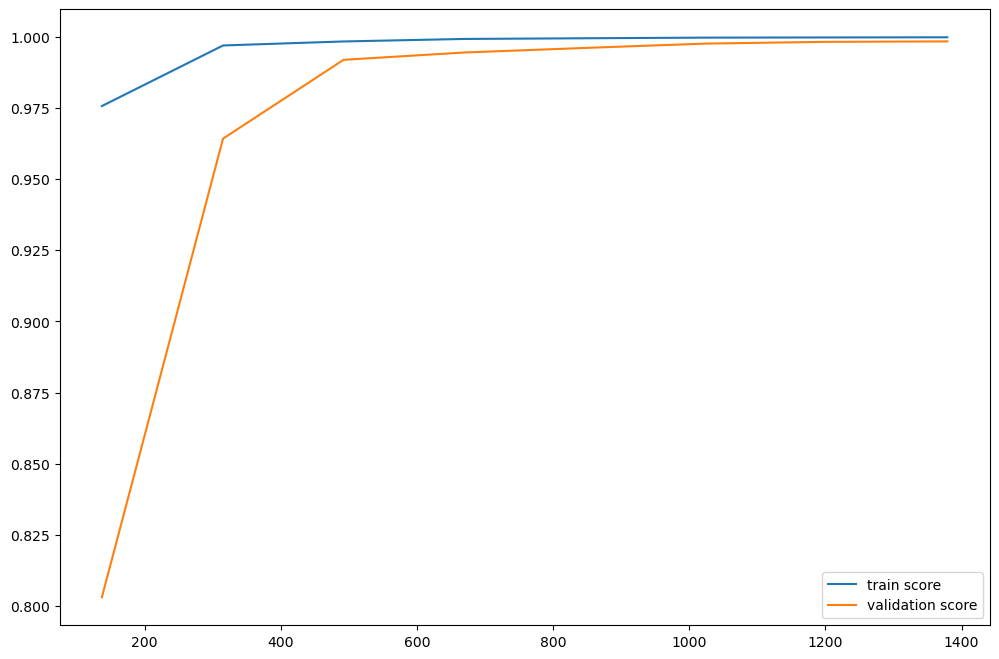

In [259]:
from sklearn.model_selection import learning_curve
N, train_score, val_score = learning_curve(model, X_train, Y_train,train_sizes=np.linspace(0.1, 1, 8))
plt.figure(figsize=(12, 8))
plt.plot(N, train_score.mean(axis=1), label='train score')
plt.plot(N, val_score.mean(axis=1), label='validation score')
plt.legend()
plt.show()

In [239]:
#  from sklearn.linear_model import LinearRegression
# from sklearn.datasets import load_boston
# from sklearn.model_selection import train_test_split

# # Charger le jeu de données Boston Housing
# boston = load_boston()
# X, y = boston.data, boston.target

# # Diviser les données en ensembles d'entraînement et de test
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Créer un modèle de régression linéaire
# model = LinearRegression()

# # Entraîner le modèle sur l'ensemble d'entraînement
# model.fit(X_train, y_train)

# # Calculer le coefficient de détermination R² sur l'ensemble d'entraînement
# r_squared = model.score(X_train, y_train)

# # Afficher le coefficient de détermination R²
# print("Coefficient de détermination R² sur l'ensemble d'entraînement :", r_squared)


In [240]:
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import cross_val_score, train_test_split
# from sklearn.datasets import load_boston

# # Charger le jeu de données Boston Housing
# boston = load_boston()
# X, y = boston.data, boston.target

# # Diviser les données en ensembles d'entraînement et de test
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Créer un modèle de régression linéaire
# model = LinearRegression()

# # Effectuer une validation croisée avec 5 folds
# scores = cross_val_score(model, X_train, y_train, cv=5)

# # Afficher les scores de validation croisée
# print("Scores de validation croisée :", scores)
# print("Score moyen de validation croisée :", scores.mean())


# regularisation

In [241]:
# def f(x):
#     return np.cos(1.5*np.pi*x)

In [242]:
# np.random.seed(0)
# n_samples=30
# X=np.sort(np.random.rand(n_samples))
# y=f(X)+np.random.randn(n_samples)*0.1


In [243]:
# polynomial_features=PolynomialFeatures(degree=15,include_bias=False)
# data=polynomial_features.fit_transform(X.shape)
# alpha=[0.0001,0.5,1,10,100]
# plt.figure(figsize=(8,8))
# for val_alpha in alpha:
#     regularization_regression=Ridge(alpha=val_alpha)
#     regularization_regression.fit(data,y)
#     X_test=np.linspace(0,1,100)
#     X_test_pred=polynomial_features.fit_transform(X_test.shape)
#     y_test_pred=regularization_regression.predict(X_test_pred)
    

In [244]:
#model= LinearRegression()
#model.fit(X,Y)

In [245]:
#y_pred=model.predict(X_test)

In [246]:
# Effectuer la validation croisée à 5 plis :
scores=cross_val_score(model,X,Y,cv=5)
# Calculer la moyenne des scores de validation obtenus à partir de la validation croisée :
print('Moyenne des scores :',scores.mean())

Moyenne des scores : -10422.200313634687


In [247]:
 #  Effectuer la regression en utilisant les 10 voisins les plus proches :
knn=KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train,Y_train)
y_pred=knn.predict(X_test)

In [248]:
# Calculer la précision du modèle :
r2=r2_score(Y_test,y_pred)
print("Coefficient de détermination (R²) :", r2)

Coefficient de détermination (R²) : 0.9773543094403407


In [249]:
scores=[]

for k in range(1,30):
    knn=KNeighborsRegressor(n_neighbors=k)
    score=cross_val_score(knn,X,Y,cv=5)
    scores.append(np.mean(score))
    
best_index = np.argmax(scores)
best_k = best_index + 1

print("Best K:", best_k, "Best Score:", scores[best_index])

Best K: 2 Best Score: -24.31453760531187


Text(0, 0.5, 'y')

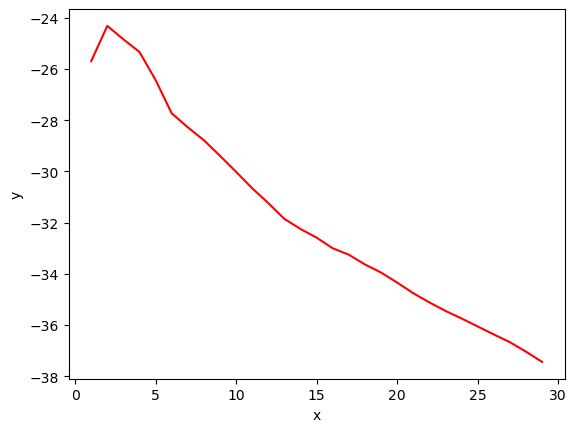

In [250]:
plt.plot(range(1,30),scores,c='r')
plt.xlabel("x")
plt.ylabel("y")

In [251]:
dtree=DecisionTreeRegressor()
dtree=dtree.fit(X,Y)

# Entrainer sur l'ensemble d'entrainement :
dtree.fit(X_train,Y_train)

# Faire des prédictions sue l'ensemble de test :
y_pred=dtree.predict(X_test)

# Evaluer le précision :
r2=r2_score(Y_test,y_pred)
print('Coefficient de détermination (R²) : ',r2)

Coefficient de détermination (R²) :  0.9916200827897308


In [252]:
# Initialiser et entraîner le modèle Bagging:
model = BaggingRegressor(base_estimator=DecisionTreeRegressor(), random_state=42)
model.fit(X_train, Y_train)

# Faire des prédictions sur les données de test :
y_pred = model.predict(X_test)

# Calculer la précision du modèle :
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

Précision du modèle :  0.995809804149452


In [253]:
# Initialiser et entraîner le modèle Adaboost :
model = AdaBoostRegressor()
model.fit(X_train, Y_train)

# Faire des prédictions sur les données de test :
y_pred = model.predict(X_test)

# Calculer la précision du modèle :
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

Précision du modèle :  0.987945863334489


In [254]:
# Initialiser et entraîner le modèle de Gradient Boosting :
model = GradientBoostingRegressor()
model.fit(X_train, Y_train)




# Faire des prédictions sur les données de test :
y_pred = model.predict(X_test)

# Calculer la précision du modèle :
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

Précision du modèle :  0.9972570893974669


In [255]:
# Définir les modèles de base
base_models = [
    ('Linear', LinearRegression()),
    ('knn', KNeighborsRegressor())]#,('svm', SVC())]

# Initialiser le modèle Stacking 
model = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())

# Entraîner le modèle Stacking
model.fit(X_train, Y_train)

# Faire des prédictions sur les données de test
y_pred = model.predict(X_test)

# Calculer la précision du modèle
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

Précision du modèle :  0.9997651474554103


In [256]:
# Initialiser et entraîner le modèle Random Forest :
model = RandomForestRegressor()
model.fit(X_train, Y_train)

# Faire des prédictions sur les données de test
y_pred = model.predict(X_test)

# Calculer la précision du modèle
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

Précision du modèle :  0.9963462486647456


In [257]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)
y_means = kmeans.predict(X)
print(y_means)

[0 0 0 ... 1 1 1]


In [258]:
# Instancier le modèle SVM avec les paramètres souhaités
svm = SVR(kernel='rbf', C=1.0, random_state=42)

# Entraîner le modèle sur l'ensemble d'entraînement
svm.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred = svm.predict(X_test)

# Évaluer les performances du modèle en utilisant une métrique appropriée
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

TypeError: __init__() got an unexpected keyword argument 'random_state'